In [12]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
# Variables
path = f"/datasets/multi-view-pig-posture-recognition"
train1_path = f"{path}/train1.csv"
train1_images_path = f"{path}/train1_images"
train2_path = f"{path}/train2.csv"
train2_images_path = f"{path}/train2_images"
test_path = f"{path}/test.csv"
test_images_path = f"{path}/test_images"
sample_submission_path = f"{path}/sample_submission.csv"
txt_path = f"{path}/pig_posture_classes.txt"

In [18]:
# convert formats
train1_df = pd.read_csv(train1_path)
train2_df = pd.read_csv(train2_path)
test_df = pd.read_csv(test_path)
sample_submission_df = pd.read_csv(sample_submission_path)
# print the first line of each csv
print("Train1 DataFrame:")
print(train1_df.head(1))
print("\nTrain2 DataFrame:")
print(train2_df.head(1))
print("\nTest DataFrame:")
print(test_df.head(1))
print("\nSample Submission DataFrame:")
print(sample_submission_df.head(1))

Train1 DataFrame:
                                     row_id  \
0  train_pen1_orb_cam1_20250108_085204_0000   

                            image_id  width  height  \
0  pen1_orb_cam1_20250108_085204.jpg   1920    1080   

                         bbox  class_id  
0  [1031.5,368.0,349.0,435.0]         0  

Train2 DataFrame:
                                     row_id  \
0  train_pen1_orb_cam1_20250108_085204_0000   

                            image_id  width  height  \
0  pen1_orb_cam1_20250108_085204.jpg   1920    1080   

                         bbox  class_id  
0  [1031.5,368.0,349.0,435.0]         0  

Test DataFrame:
                                    row_id                           image_id  \
0  test_pen1_tur_cam1_20250920_174649_0000  pen1_tur_cam1_20250920_174649.jpg   

   width  height                       bbox  
0   1280     720  [432.0,291.0,306.0,394.0]  

Sample Submission DataFrame:
                                    row_id  class_id
0  test_pen1_tur_cam1_202509

In [28]:
# convert class_id to string using the txt
with open(txt_path, 'r') as f:
    class_names = [line.strip() for line in f.readlines()]
class_id_to_name = {i: name for i, name in enumerate(class_names)}

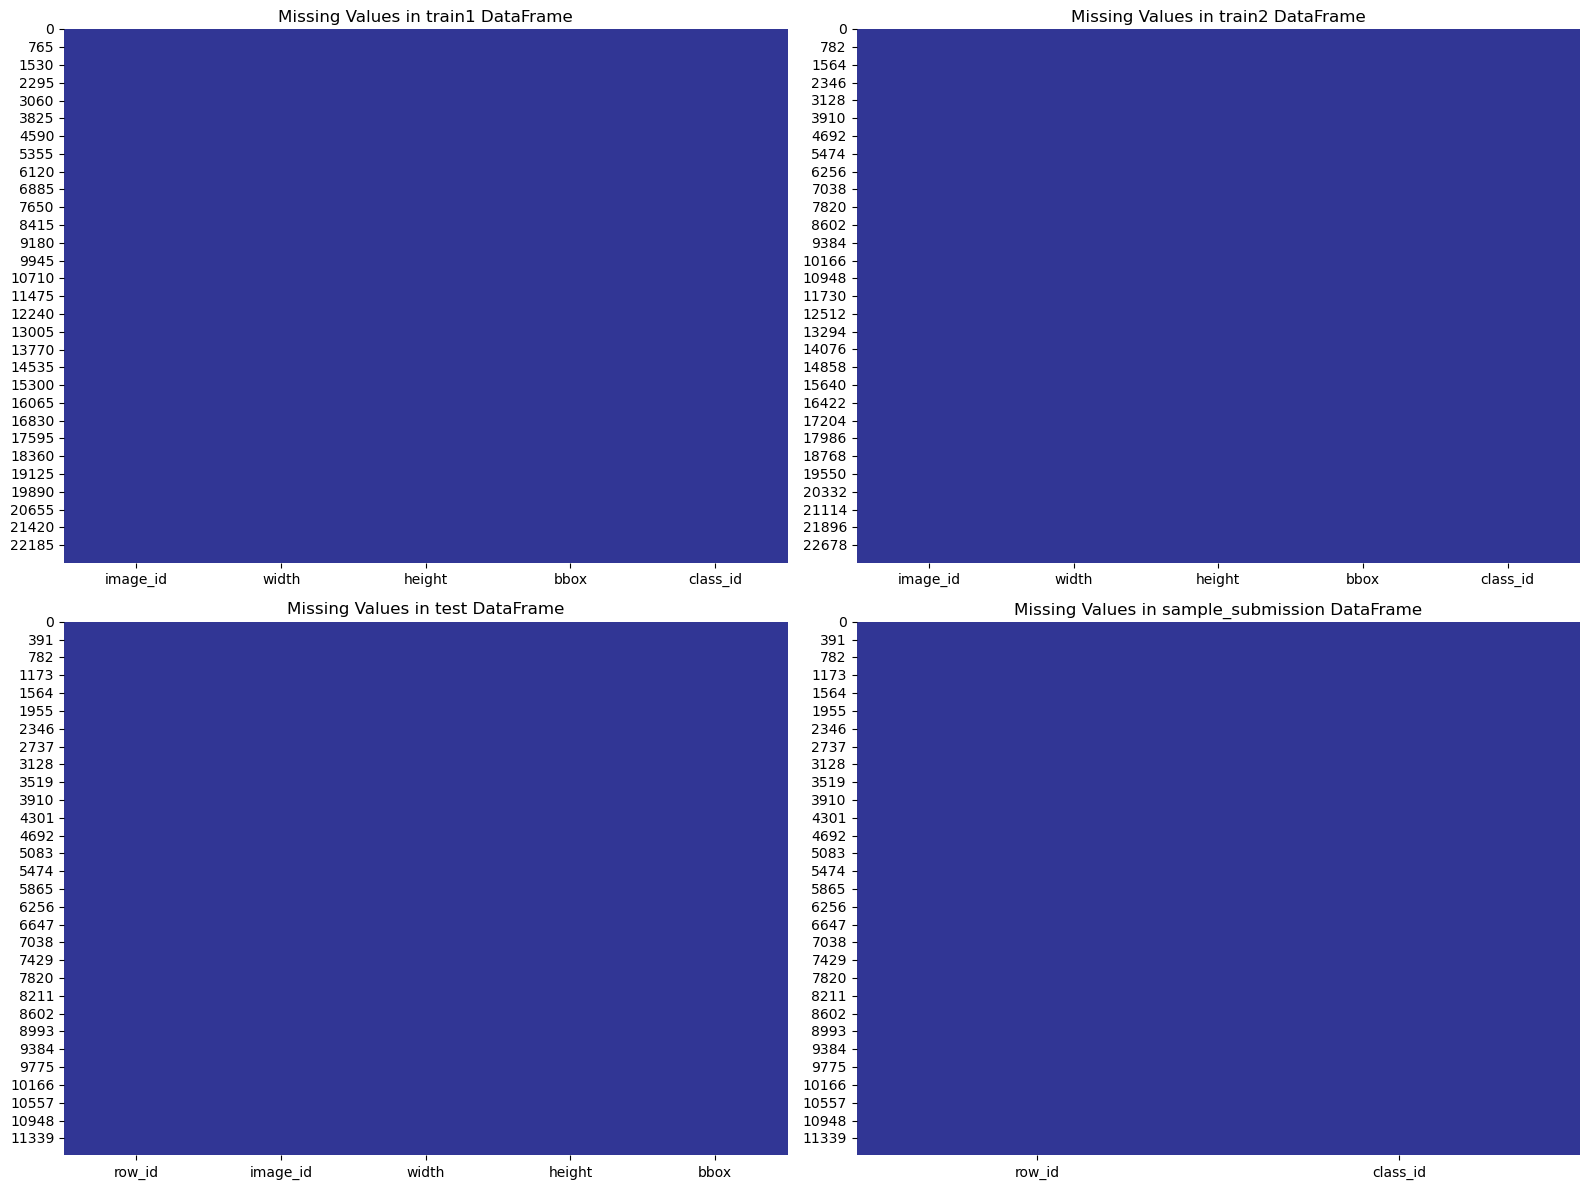

In [54]:
data = {
    "train1": train1_df,
    "train2": train2_df,
    "test": test_df,
    "sample_submission": sample_submission_df
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (name, df) in enumerate(data.items()):
    sns.heatmap(df.isnull(), cbar=False, cmap='RdYlBu_r', ax=axes[i])
    axes[i].set_title(f'Missing Values in {name} DataFrame')

plt.tight_layout()
plt.show()

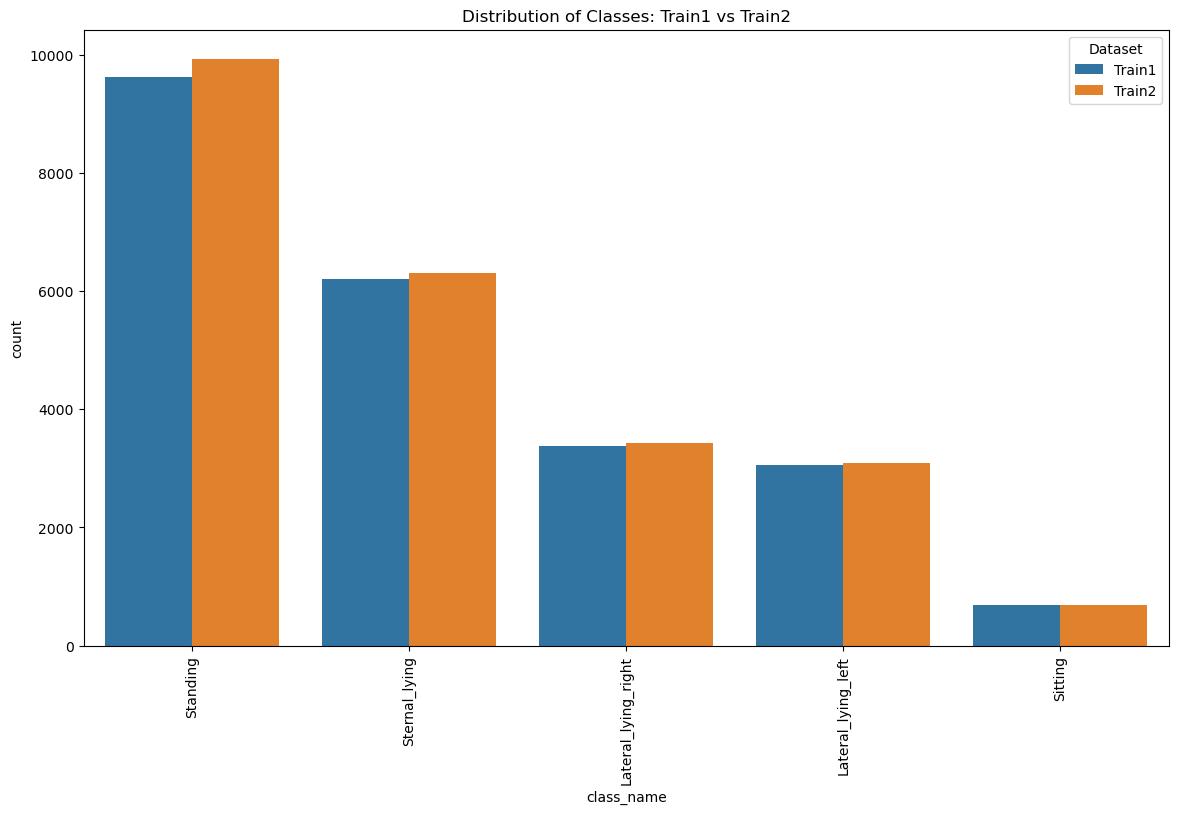

In [30]:
# Create combined DataFrame with source information and convert class_id to names
train1_labeled = train1_df.copy()
train1_labeled['source'] = 'Train1'
train1_labeled['class_name'] = train1_labeled['class_id'].map(class_id_to_name)

train2_labeled = train2_df.copy()
train2_labeled['source'] = 'Train2'
train2_labeled['class_name'] = train2_labeled['class_id'].map(class_id_to_name)

combined_labeled_df = pd.concat([train1_labeled, train2_labeled])

# Create single plot with different colors for each dataset
plt.figure(figsize=(14, 8))
sns.countplot(data=combined_labeled_df, x='class_name', hue='source', 
              order=combined_labeled_df['class_name'].value_counts().index)
plt.title('Distribution of Classes: Train1 vs Train2')
plt.xticks(rotation=90)
plt.legend(title='Dataset')
plt.show()

In [31]:
#drop row_id from test1 and test2 since it contains redundant information
train1_df.drop(columns=['row_id'], inplace=True)
train2_df.drop(columns=['row_id'], inplace=True)
train1_df.head()

,image_id,width,height,bbox,class_id
0,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


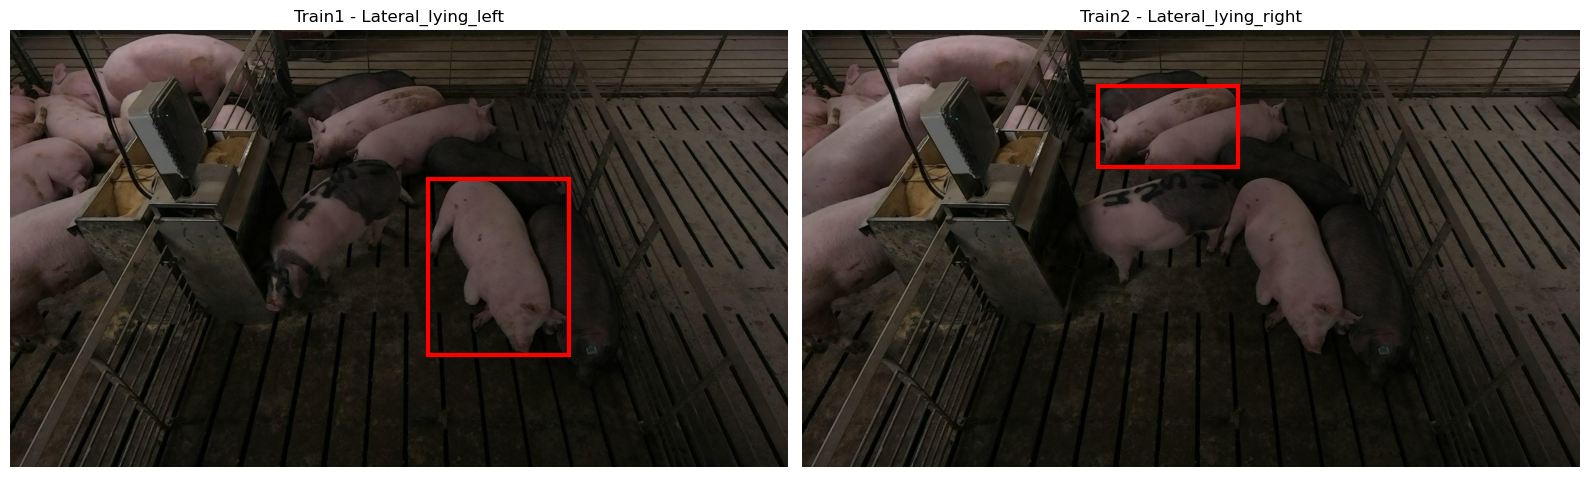

In [52]:
import cv2
from matplotlib.patches import Rectangle
import ast

# Get first row from each dataset. Wer are picking 2 different immages as a proof of concept
first_train1 = train1_df.iloc[0]
first_train2 = train2_df.iloc[30]

# Load images
img1_path = f"{train1_images_path}/{first_train1['image_id']}"
img2_path = f"{train2_images_path}/{first_train2['image_id']}"

img1 = cv2.imread(img1_path)
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.imread(img2_path)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Parse bbox coordinates (assuming format: [x, y, width, height])
bbox1 = ast.literal_eval(first_train1['bbox']) if isinstance(first_train1['bbox'], str) else first_train1['bbox']
bbox2 = ast.literal_eval(first_train2['bbox']) if isinstance(first_train2['bbox'], str) else first_train2['bbox']

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot first image with bbox
axes[0].imshow(img1)
rect1 = Rectangle((bbox1[0], bbox1[1]), bbox1[2], bbox1[3], linewidth=3, edgecolor='red', facecolor='none')
axes[0].add_patch(rect1)
axes[0].set_title(f'Train1 - {class_id_to_name[first_train1["class_id"]]}')
axes[0].axis('off')

# Plot second image with bbox
axes[1].imshow(img2)
rect2 = Rectangle((bbox2[0], bbox2[1]), bbox2[2], bbox2[3], linewidth=3, edgecolor='red', facecolor='none')
axes[1].add_patch(rect2)
axes[1].set_title(f'Train2 - {class_id_to_name[first_train2["class_id"]]}')
axes[1].axis('off')

plt.tight_layout()
plt.show()